# Phase 9 - Evaluation with RAGAS

**Goal**: Build a comprehensive evaluation pipeline using RAGAS metrics to compare three RAG pipeline configurations end-to-end.

## What this notebook does

1. **Ground truth** - Load manually written reference answers for the 25 benchmark questions (evaluate a 12-question subset: N_EVAL=3 per category).
2. **Pipeline evaluation** - Run three pipeline configs through RAGAS:
   - `naive`: dense similarity only (baseline)
   - `hybrid_reranked`: BM25 + dense + cross-encoder reranking
   - `hyde`: HyDE query expansion + dense similarity
3. **RAGAS metrics**: Faithfulness, Answer Relevancy, Context Precision, Context Recall
4. **Visualization**: Radar chart and bar chart per metric

## RAGAS metrics overview

| Metric | Measures | Requires |
|--------|----------|----------|
| **Faithfulness** | Is the answer supported by the context? (no hallucinations) | LLM |
| **Answer Relevancy** | Does the answer address the question? | LLM + Embeddings |
| **Context Precision** | Are retrieved docs relevant to the question? | LLM |
| **Context Recall** | Does context cover all info needed to answer? | LLM + ground_truth |

> **Note on ground truths**: Reference answers were written manually - not generated by Mistral - to avoid circular evaluation bias. All RAGAS scoring calls use local Mistral 7B via Ollama.

## 0. Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress RAGAS deprecation warnings (LangchainLLMWrapper is deprecated but still works)
warnings.filterwarnings("ignore", category=DeprecationWarning)

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# LangChain imports
from langchain_ollama import ChatOllama
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# RAGAS
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# Paths
EVAL_DIR     = PROJECT_ROOT / "data" / "evaluation"
RESULTS_DIR  = PROJECT_ROOT / "results"
PERSIST_DIR  = PROJECT_ROOT / "vectorstore" / "chroma_db"
MODELS_YAML  = PROJECT_ROOT / "configs" / "models.yaml"
GT_PATH      = EVAL_DIR / "ground_truth.json"
RESULTS_PATH = RESULTS_DIR / "ragas_evaluation.json"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Models
LLM_MODEL = "mistral:7b"

# Evaluation subset - RAGAS is slow (many LLM calls per question)
# We evaluate on N_EVAL questions per category to keep runtime manageable
N_EVAL = 3   # 3 questions per category -> 12 total (4 categories)

print("Setup complete.")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Chroma DB    : {PERSIST_DIR}")
print(f"  Eval subset  : {N_EVAL} questions/category")

/home/hunganh/miniconda3/envs/test_env/lib/python3.13/site-packages/instructor/providers/gemini/client.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai  # type: ignore[import-not-found]


Setup complete.
  Project root : /home/hunganh/Code/Python/course_qa_assist
  Chroma DB    : /home/hunganh/Code/Python/course_qa_assist/vectorstore/chroma_db
  Eval subset  : 3 questions/category


In [ ]:
from src.embeddings.models import create_from_registry

# Initialize models - same pattern as notebooks 04-08
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
llm = ChatOllama(model=LLM_MODEL, temperature=0.0)

# Use a JSON-formatted LLM for RAGAS to reduce parser errors
ragas_eval_llm = ChatOllama(model=LLM_MODEL, temperature=0.0, format="json")

EMBED_MODEL = emb_info.name

# RAGAS wrappers for local models
ragas_llm = LangchainLLMWrapper(ragas_eval_llm)
ragas_emb = LangchainEmbeddingsWrapper(embeddings)

# Warmup
_ = llm.invoke("Hi")
_ = ragas_eval_llm.invoke("Return a JSON object with key ok and value true.")
print(f"LLM ready : {LLM_MODEL}")
print(f"Embeddings: {EMBED_MODEL}")

LLM ready : mistral:7b
Embeddings: mxbai_large


## 1. Ground Truth

RAGAS `context_recall` requires a reference answer (`ground_truth`) to measure whether the retrieved context contains all the information needed to answer.

The ground truths in `data/evaluation/ground_truth.json` were **written manually** based on the research paper knowledge. This is critical: using the same model (Mistral 7B) to both generate answers and evaluate them creates circular scoring bias.

Each ground truth is a 3-5 sentence factual summary covering the key points a correct answer must include.

In [3]:
# Load manually written ground truths
with open(GT_PATH, "r", encoding="utf-8") as f:
    ground_truths = json.load(f)

print(f"Loaded {len(ground_truths)} ground truths from {GT_PATH.name}")
print(f"\nSample:")
sample = ground_truths[0]
print(f"  Q: {sample['question']}")
print(f"  A: {sample['ground_truth'][:200]}...")

Loaded 12 ground truths from ground_truth.json

Sample:
  Q: What is the role of an ML System in the AI lifecycle?
  A: An ML system encompasses the end-to-end lifecycle of machine learning models, integrating data engineering, model training, efficient execution, and deployment into a cohesive pipeline. It bridges the...


In [4]:
# Select N_EVAL questions per category for evaluation
from collections import defaultdict

by_category = defaultdict(list)
for item in ground_truths:
    by_category[item["category"]].append(item)

eval_questions = []
for cat, items in by_category.items():
    subset = items[:N_EVAL]
    eval_questions.extend(subset)
    print(f"  {cat}: {len(subset)} questions")

print(f"\nTotal evaluation questions: {len(eval_questions)}")

  conceptual: 3 questions
  technical: 3 questions
  how_to: 3 questions
  error_related: 3 questions

Total evaluation questions: 12


## 2. Vector Store Setup

Load the raw core docs, chunk them, and build a dedicated ChromaDB collection for this evaluation. The collection is reused on subsequent runs if it already exists.

In [5]:
from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus

# Same loading pipeline as all previous phases (04-08)
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Core docs: {len(core_docs)} (from {len(docs)} raw, {len(cleaned_docs)} cleaned)")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Core docs: 2666 (from 2703 raw, 2666 cleaned)


In [6]:
from src.ingestion.chunkers import chunk_recursive

# Chunk the core docs - same function and parameters as notebooks 04-08
chunking_result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = chunking_result.chunks
print(f"Chunks: {len(chunks)}")

# Build or reuse ChromaDB collection
COLLECTION_NAME = "ragas_eval_mxbai"

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(PERSIST_DIR),
)

existing = vectorstore.get()
if len(existing["ids"]) == 0:
    print(f"Building collection '{COLLECTION_NAME}' ({len(chunks)} chunks)...")
    import time
    t0 = time.perf_counter()
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        persist_directory=str(PERSIST_DIR),
    )
    print(f"Indexed in {time.perf_counter()-t0:.1f}s")
else:
    print(f"Reusing existing collection '{COLLECTION_NAME}' ({len(existing['ids'])} docs)")

Chunks: 9137
Reusing existing collection 'ragas_eval_mxbai' (9137 docs)


In [7]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(chunks, k=5)
print(f"BM25 retriever built ({len(chunks)} docs)")

BM25 retriever built (9137 docs)


## 3. Pipeline Definitions

Three configurations to evaluate:

| Config | Retrieval | Reranking | Query Transform |
|--------|-----------|-----------|----------------|
| `naive` | Dense similarity (top-5) | No | None |
| `hybrid_reranked` | BM25 + Dense, top-20 candidates | Cross-encoder | None |
| `hyde` | HyDE expansion + dense similarity | No | HyDE |

Each config uses the same generation chain: a simple RAG prompt with Mistral 7B.

In [8]:
# Shared RAG generation prompt
RAG_PROMPT = ChatPromptTemplate.from_messages([
    (
        "human",
        """Answer the following question using ONLY the provided context.
If the context does not contain enough information, say so.
Be concise and accurate.

Context:
{context}

Question: {question}

Answer:""",
    ),
])

def make_rag_chain(retriever):
    """Build a simple RAG chain: retrieve -> format -> generate."""
    from langchain_core.runnables import RunnablePassthrough, RunnableLambda

    def format_docs(docs):
        return "\n\n".join(
            f"[{i+1}] {d.page_content[:800]}" for i, d in enumerate(docs)
        )

    chain = (
        {
            "context": retriever | RunnableLambda(format_docs),
            "question": RunnablePassthrough(),
        }
        | RAG_PROMPT
        | llm
        | StrOutputParser()
    )
    return chain

print("RAG prompt defined.")

RAG prompt defined.


In [9]:
# Config 1: Naive - dense similarity top-5
naive_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
naive_chain = make_rag_chain(naive_retriever)
print("Config 'naive' ready.")

Config 'naive' ready.


In [10]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document as LCDocument
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from sentence_transformers import CrossEncoder

# Config 2: Hybrid (BM25 + Dense) + Cross-encoder reranking

class HybridRerankedRetriever(BaseRetriever):
    """BM25 + dense ensemble retriever with cross-encoder reranking."""

    base_retriever: object
    model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    top_k: int = 5
    _cross_encoder: object = None

    class Config:
        arbitrary_types_allowed = True

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> list[LCDocument]:
        if self._cross_encoder is None:
            object.__setattr__(self, "_cross_encoder", CrossEncoder(self.model_name))
        candidates = self.base_retriever.invoke(query)
        pairs = [(query, d.page_content) for d in candidates]
        scores = self._cross_encoder.predict(pairs).tolist()
        ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
        return [doc for doc, _ in ranked[:self.top_k]]

# Ensemble retriever: BM25 + Dense, 20 candidates each
dense_retriever_20 = vectorstore.as_retriever(search_kwargs={"k": 20})
bm25_retriever_20 = BM25Retriever.from_documents(chunks, k=20)

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever_20, dense_retriever_20],
    weights=[0.5, 0.5],
)

hybrid_reranked_retriever = HybridRerankedRetriever(
    base_retriever=ensemble_retriever,
    top_k=5,
)
hybrid_reranked_chain = make_rag_chain(hybrid_reranked_retriever)
print("Config 'hybrid_reranked' ready.")

Config 'hybrid_reranked' ready.


In [11]:
from langchain_core.runnables import RunnableLambda
from src.chains.query_translation import generate_hyde_doc

# Config 3: HyDE - generate hypothetical document, then retrieve

class HyDERetriever(BaseRetriever):
    """Retriever that first generates a hypothetical doc, then retrieves by it."""

    vectorstore: object
    llm: object
    k: int = 5

    class Config:
        arbitrary_types_allowed = True

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> list[LCDocument]:
        hyp_doc = generate_hyde_doc(self.llm, query)  # llm first, query second
        return self.vectorstore.similarity_search(hyp_doc, k=self.k)

hyde_retriever = HyDERetriever(vectorstore=vectorstore, llm=llm, k=5)
hyde_chain = make_rag_chain(hyde_retriever)
print("Config 'hyde' ready.")

Config 'hyde' ready.


## 4. Collect Samples for Each Configuration

Run retrieval + generation for all evaluation questions. This is the slow step.

Expected time per config: ~1-2 min for 12 questions (retrieval + Mistral generation).

In [12]:
import time
from src.evaluation.evaluator import EvalSample

def collect_samples_simple(chain, retriever, questions):
    """Run chain+retriever on each question, return EvalSample list."""
    samples = []
    for i, q in enumerate(questions):
        start = time.perf_counter()
        docs = retriever.invoke(q["question"])
        contexts = [d.page_content for d in docs]
        answer = chain.invoke(q["question"])
        if not isinstance(answer, str):
            answer = str(answer)
        latency_ms = (time.perf_counter() - start) * 1000
        samples.append(EvalSample(
            question=q["question"],
            answer=answer,
            contexts=contexts,
            ground_truth=q["ground_truth"],
            category=q["category"],
            question_id=q["id"],
            latency_ms=latency_ms,
        ))
        print(f"  [{i+1:02d}/{len(questions)}] {q['id']} ({latency_ms:.0f} ms)")
    return samples

configs = [
    ("naive",            naive_chain,            naive_retriever),
    ("hybrid_reranked",  hybrid_reranked_chain,  hybrid_reranked_retriever),
    ("hyde",             hyde_chain,             hyde_retriever),
]

all_samples: dict[str, list] = {}

for config_name, chain, retriever in configs:
    print(f"\n--- Collecting samples: {config_name} ---")
    t0 = time.perf_counter()
    samples = collect_samples_simple(chain, retriever, eval_questions)
    all_samples[config_name] = samples
    print(f"Done in {time.perf_counter()-t0:.1f}s")


--- Collecting samples: naive ---
  [01/12] c01 (4194 ms)
  [02/12] c02 (1587 ms)
  [03/12] c03 (2649 ms)
  [04/12] t01 (2370 ms)
  [05/12] t02 (1577 ms)
  [06/12] t03 (1928 ms)
  [07/12] h01 (2000 ms)
  [08/12] h02 (2992 ms)
  [09/12] h03 (2859 ms)
  [10/12] e01 (1877 ms)
  [11/12] e02 (2870 ms)
  [12/12] e03 (1712 ms)
Done in 28.6s

--- Collecting samples: hybrid_reranked ---


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [01/12] c01 (12225 ms)
  [02/12] c02 (2802 ms)
  [03/12] c03 (2248 ms)
  [04/12] t01 (2873 ms)
  [05/12] t02 (2419 ms)
  [06/12] t03 (2431 ms)
  [07/12] h01 (1943 ms)
  [08/12] h02 (2658 ms)
  [09/12] h03 (2626 ms)
  [10/12] e01 (3001 ms)
  [11/12] e02 (1490 ms)
  [12/12] e03 (2104 ms)
Done in 38.8s

--- Collecting samples: hyde ---
  [01/12] c01 (7213 ms)
  [02/12] c02 (8774 ms)
  [03/12] c03 (9438 ms)
  [04/12] t01 (11965 ms)
  [05/12] t02 (7568 ms)
  [06/12] t03 (5267 ms)
  [07/12] h01 (6106 ms)
  [08/12] h02 (7975 ms)
  [09/12] h03 (8140 ms)
  [10/12] e01 (7281 ms)
  [11/12] e02 (7175 ms)
  [12/12] e03 (7385 ms)
Done in 94.3s


## 5. RAGAS Evaluation

Run the four RAGAS metrics on the collected samples for each configuration.

**Estimated time**: ~3-5 min per config (RAGAS makes multiple LLM calls per question).

> RAGAS internally calls the LLM to:
> - Decompose the answer into statements (faithfulness)
> - Generate questions from the answer (answer_relevancy)
> - Score each context chunk (context_precision, context_recall)

In [13]:
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas import evaluate
from datasets import Dataset

# Instantiate metric objects (RAGAS 0.4.x requires instances, not singletons)
faithfulness_metric    = Faithfulness(llm=ragas_llm)
answer_relevancy_metric = AnswerRelevancy(llm=ragas_llm, embeddings=ragas_emb)
context_precision_metric = ContextPrecision(llm=ragas_llm)
context_recall_metric   = ContextRecall(llm=ragas_llm)

METRICS = [
    faithfulness_metric,
    answer_relevancy_metric,
    context_precision_metric,
    context_recall_metric,
]
print(f"RAGAS metrics configured with local {LLM_MODEL} + {EMBED_MODEL}.")

RAGAS metrics configured with local mistral:7b + mxbai_large.


In [14]:
from ragas.run_config import RunConfig

eval_results: dict[str, dict] = {}

run_cfg = RunConfig(
    timeout=600,      # 10 min per LLM call (Mistral local can be slow)
    max_retries=5,
    max_workers=1,    # sequential to avoid overwhelming Ollama
)

for config_name, samples in all_samples.items():
    print(f"\n--- RAGAS evaluation: {config_name} ({len(samples)} samples) ---")
    t0 = time.perf_counter()

    records = [
        {
            "question": s.question,
            "answer": s.answer,
            "contexts": s.contexts,
            "ground_truth": s.ground_truth,
        }
        for s in samples
    ]
    dataset = Dataset.from_list(records)

    result = evaluate(
        dataset=dataset,
        metrics=METRICS,
        run_config=run_cfg,
        raise_exceptions=False,
    )

    elapsed = time.perf_counter() - t0
    df = result.to_pandas()

    metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
    scores = {col: float(df[col].mean()) for col in metric_cols if col in df.columns}

    eval_results[config_name] = {
        "scores": scores,
        "df": df,
        "elapsed_s": elapsed,
        "samples": samples,
    }

    print(f"  elapsed: {elapsed:.1f}s")
    for k, v in scores.items():
        print(f"  {k}: {v:.4f}")


--- RAGAS evaluation: naive (12 samples) ---


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[19]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt context_recall_classification_prompt failed to parse output: T

  elapsed: 901.1s
  faithfulness: 0.9181
  answer_relevancy: 0.9402
  context_precision: 1.0000
  context_recall: 0.7679

--- RAGAS evaluation: hybrid_reranked (12 samples) ---


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[15]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Exception raised in Job[27]: OutputParserException(Failed to parse StringIO from completion {"classifications": [{"statement": "To implement data parallel training, you replicate the model across multiple GPUs", "reason": "The context discusses the strategy of hybrid parallelism which involves replication of models across devices.", "attributed": 1}, {"statement": "and split each batch of training data ac

  elapsed: 1082.5s
  faithfulness: 0.8542
  answer_relevancy: 0.8375
  context_precision: 1.0000
  context_recall: 0.8139

--- RAGAS evaluation: hyde (12 samples) ---


Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt n_l_i_statement_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[0]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Exception raised in Job[3]: OutputParserException(Failed to parse StringIO from completion {"classifications": [{"statement": "An ML system encompasses the end-to-end lifecycle of machine learning models", "reason": "The context discusses the complete lifecycle of ML systems, including data collection, model training, evaluation, deployment, and monitoring.", "attributed": 1}, {"statement": "it integrates data engineeri

  elapsed: 1292.9s
  faithfulness: 0.8491
  answer_relevancy: 0.8633
  context_precision: 1.0000
  context_recall: 0.7253


## 6. Results Comparison

In [15]:
METRIC_COLS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

summary_rows = []
for config_name, res in eval_results.items():
    row = {"config": config_name}
    row.update({k: round(v, 4) for k, v in res["scores"].items()})
    row["avg_score"] = round(sum(res["scores"].values()) / len(res["scores"]), 4)
    row["avg_latency_ms"] = round(sum(s.latency_ms for s in res["samples"]) / len(res["samples"]), 1)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("config")
print(summary_df.to_string())

                 faithfulness  answer_relevancy  context_precision  context_recall  avg_score  avg_latency_ms
config                                                                                                       
naive                  0.9181            0.9402                1.0          0.7679     0.9065          2384.6
hybrid_reranked        0.8542            0.8375                1.0          0.8139     0.8764          3235.0
hyde                   0.8491            0.8633                1.0          0.7253     0.8594          7857.3


## 7. Visualizations

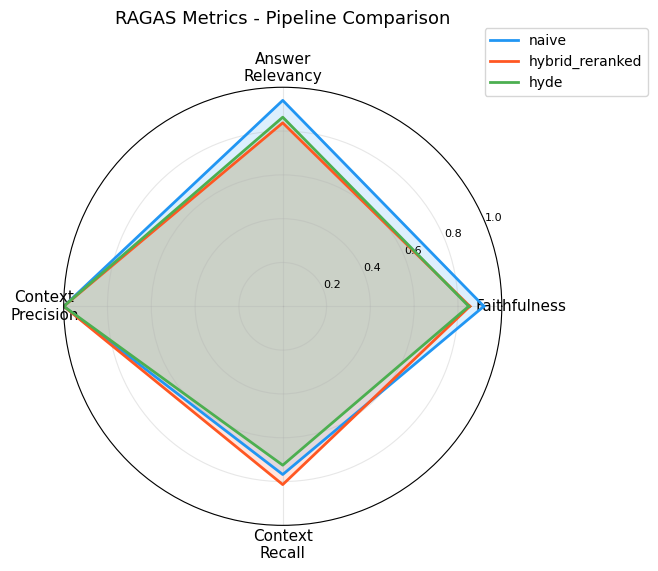

Radar chart saved.


In [16]:
# Radar chart - each config as a polygon across 4 metrics
categories = ["Faithfulness", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"]
metric_keys = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close polygon

colors = ["#2196F3", "#FF5722", "#4CAF50"]
config_names = list(eval_results.keys())

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, config_name in enumerate(config_names):
    scores = eval_results[config_name]["scores"]
    values = [scores.get(k, 0) for k in metric_keys]
    values += values[:1]

    ax.plot(angles, values, linewidth=2, color=colors[i], label=config_name)
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
ax.set_title("RAGAS Metrics - Pipeline Comparison", size=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ragas_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Radar chart saved.")

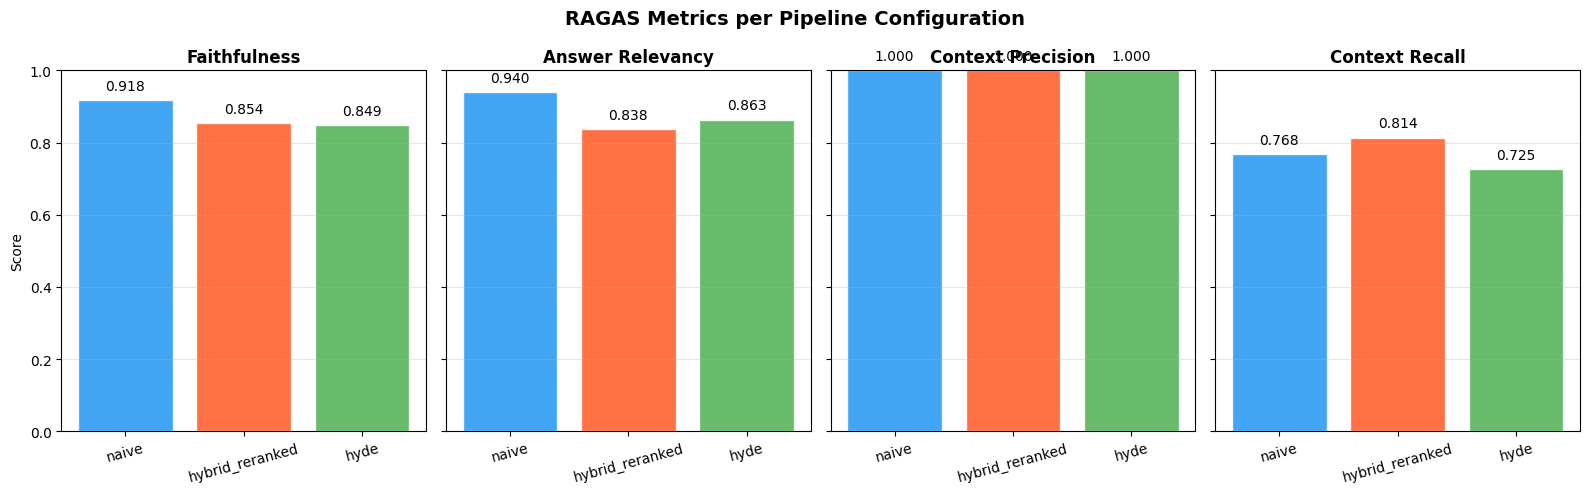

Bar chart saved.


In [17]:
# Bar chart - side-by-side per metric
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
metric_labels = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]

for ax, metric_key, metric_label in zip(axes, metric_keys, metric_labels):
    vals = [eval_results[c]["scores"].get(metric_key, 0) for c in config_names]
    bars = ax.bar(config_names, vals, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(metric_label, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=10,
        )

fig.suptitle("RAGAS Metrics per Pipeline Configuration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ragas_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Bar chart saved.")

In [18]:
# Per-category breakdown for each config
print("Per-category average scores:\n")

for config_name, res in eval_results.items():
    df = res["df"].copy()
    # Attach category from eval_questions
    cat_map = {q["question"]: q["category"] for q in eval_questions}
    df["category"] = df["user_input"].map(cat_map)

    cat_df = df.groupby("category")[metric_keys].mean().round(4)
    print(f"Config: {config_name}")
    print(cat_df.to_string())
    print()

Per-category average scores:

Config: naive
               faithfulness  answer_relevancy  context_precision  context_recall
category                                                                        
conceptual           0.9167            0.9303                1.0          0.8095
error_related        0.8667            0.9471                1.0          0.7500
how_to               0.8889            0.9649                1.0          0.6667
technical            1.0000            0.9184                1.0          0.8750

Config: hybrid_reranked
               faithfulness  answer_relevancy  context_precision  context_recall
category                                                                        
conceptual           0.7500            0.9236                1.0          0.8519
error_related        0.8333            0.6631                1.0          0.6389
how_to               0.9444            0.9010                1.0          0.8333
technical            0.8889            0

## 8. Save Results

In [19]:
output = {
    "experiment": "phase9_ragas_evaluation",
    "embed_model": EMBED_MODEL,
    "llm_model": LLM_MODEL,
    "n_questions": len(eval_questions),
    "results": [
        {
            "config": config_name,
            "scores": res["scores"],
            "avg_score": sum(res["scores"].values()) / len(res["scores"]),
            "avg_latency_ms": sum(s.latency_ms for s in res["samples"]) / len(res["samples"]),
            "eval_elapsed_s": res["elapsed_s"],
        }
        for config_name, res in eval_results.items()
    ],
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Results saved -> {RESULTS_PATH}")

Results saved -> /home/hunganh/Code/Python/course_qa_assist/results/ragas_evaluation.json


## 9. Cleanup

In [20]:
# Delete evaluation collection to free disk space
import chromadb

client = chromadb.PersistentClient(path=str(PERSIST_DIR))
existing_collections = [c.name for c in client.list_collections()]

if COLLECTION_NAME in existing_collections:
    client.delete_collection(COLLECTION_NAME)
    print(f"Deleted collection '{COLLECTION_NAME}'")
else:
    print(f"Collection '{COLLECTION_NAME}' not found (already deleted?)")

print("Cleanup complete.")

Deleted collection 'ragas_eval_mxbai'
Cleanup complete.


## 10. Conclusion

### RAGAS Evaluation Results (n=12 questions)

| Config | Faithfulness | Answer Relevancy | Context Precision | Context Recall | Avg Score | Avg Latency (ms) |
|---|---|---|---|---|---|---|
| naive | **0.9181** | **0.9402** | **1.0000** | 0.7679 | **0.9065** | **2384.6** |
| hybrid_reranked | 0.8542 | 0.8375 | **1.0000** | **0.8139** | 0.8764 | 3235.0 |
| hyde | 0.8491 | 0.8633 | **1.0000** | 0.7253 | 0.8594 | 7857.3 |

### Key Findings

1. **`naive` is the best overall on this run.** It has the highest avg score (0.9065) and the fastest latency (2.38 s).
2. **`hybrid_reranked` improves context recall but loses faithfulness.** Recall increases to 0.8139, but faithfulness and answer relevancy drop vs `naive`.
3. **Context precision is saturated across all configs.** Scores are ~1.00, suggesting the retriever already surfaces relevant chunks regardless of strategy.
4. **HyDE is the slowest and lowest-scoring trade-off.** It is ~3.3x slower than `naive` with a lower avg score.
5. **Sample size is modest (12 questions).** Re-run on a larger subset before finalizing the default pipeline.

### Recommendation for Phase 10

Use `naive` as the default configuration for best quality and latency on this dataset, and consider `hybrid_reranked` when recall is the priority.